In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv(
    "../outputs/feature_engineered_retail.csv"
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
customer_revenue = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
      .reset_index()
)

customer_revenue.head()

,CustomerID,Revenue
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [5]:
customer_revenue = customer_revenue.sort_values(
    by="Revenue",
    ascending=False
)

customer_revenue.head()

,CustomerID,Revenue
1689,14646.0,280206.02
4201,18102.0,259657.30
3728,17450.0,194390.79
3008,16446.0,168472.50
1879,14911.0,143711.17


In [6]:
customer_revenue["CumulativeRevenue"] = (
    customer_revenue["Revenue"]
    .cumsum()
)

customer_revenue["RevenuePercent"] = (
    customer_revenue["Revenue"]
    / customer_revenue["Revenue"].sum()
) * 100

customer_revenue["CumulativePercent"] = (
    customer_revenue["RevenuePercent"]
    .cumsum()
)

customer_revenue.head()

,CustomerID,Revenue,CumulativeRevenue,RevenuePercent,CumulativePercent
1689,14646.0,280206.02,280206.02,3.152914,3.152914
4201,18102.0,259657.30,539863.32,2.921697,6.074610
3728,17450.0,194390.79,734254.11,2.187310,8.261920
3008,16446.0,168472.50,902726.61,1.895674,10.157594
1879,14911.0,143711.17,1046437.78,1.617056,11.774650


In [7]:
pareto_customers = customer_revenue[
    customer_revenue["CumulativePercent"] <= 80
]

pareto_customers.head()

,CustomerID,Revenue,CumulativeRevenue,RevenuePercent,CumulativePercent
1689,14646.0,280206.02,280206.02,3.152914,3.152914
4201,18102.0,259657.30,539863.32,2.921697,6.074610
3728,17450.0,194390.79,734254.11,2.187310,8.261920
3008,16446.0,168472.50,902726.61,1.895674,10.157594
1879,14911.0,143711.17,1046437.78,1.617056,11.774650


In [8]:
num_pareto_customers = pareto_customers["CustomerID"].nunique()

total_customers = customer_revenue["CustomerID"].nunique()

pareto_percentage = (
    num_pareto_customers
    / total_customers
) * 100

print(f"Customers contributing 80% revenue: {num_pareto_customers}")
print(f"Percentage of customer base: {pareto_percentage:.2f}%")

Customers contributing 80% revenue: 1129
Percentage of customer base: 26.03%


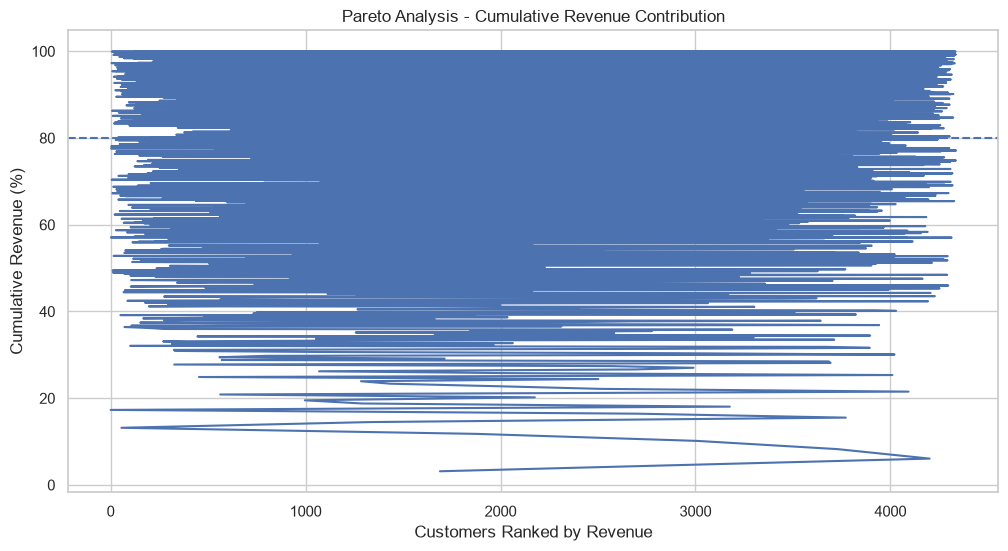

In [9]:
plt.figure(figsize=(12,6))

plt.plot(
    customer_revenue.index,
    customer_revenue["CumulativePercent"]
)

plt.axhline(
    y=80,
    linestyle="--"
)

plt.title("Pareto Analysis - Cumulative Revenue Contribution")
plt.xlabel("Customers Ranked by Revenue")
plt.ylabel("Cumulative Revenue (%)")

plt.show()

In [10]:
pareto_revenue = pareto_customers["Revenue"].sum()

remaining_revenue = (
    customer_revenue["Revenue"].sum()
    - pareto_revenue
)

comparison = pd.DataFrame({
    "Group": [
        "Top Revenue Customers",
        "Remaining Customers"
    ],
    "Revenue": [
        pareto_revenue,
        remaining_revenue
    ]
})

comparison

,Group,Revenue
0,Top Revenue Customers,7109056.501
1,Remaining Customers,1778152.393


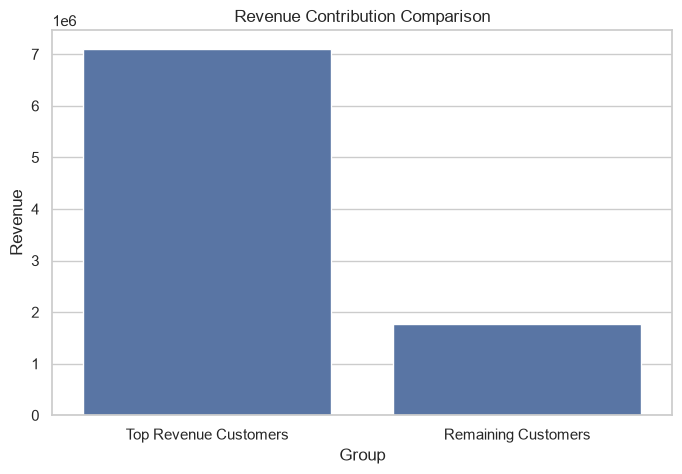

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Group",
    y="Revenue"
)

plt.title("Revenue Contribution Comparison")

plt.show()

In [12]:
top_10_customers = (
    customer_revenue
    .head(10)
)

top_10_customers

,CustomerID,Revenue,CumulativeRevenue,RevenuePercent,CumulativePercent
1689,14646.0,280206.02,280206.02,3.152914,3.152914
4201,18102.0,259657.30,539863.32,2.921697,6.074610
3728,17450.0,194390.79,734254.11,2.187310,8.261920
3008,16446.0,168472.50,902726.61,1.895674,10.157594
1879,14911.0,143711.17,1046437.78,1.617056,11.774650
55,12415.0,124914.53,1171352.31,1.405554,13.180205
1333,14156.0,117210.08,1288562.39,1.318863,14.499067
3771,17511.0,91062.38,1379624.77,1.024645,15.523713
2702,16029.0,80850.84,1460475.61,0.909744,16.433457
0,12346.0,77183.60,1537659.21,0.868480,17.301936


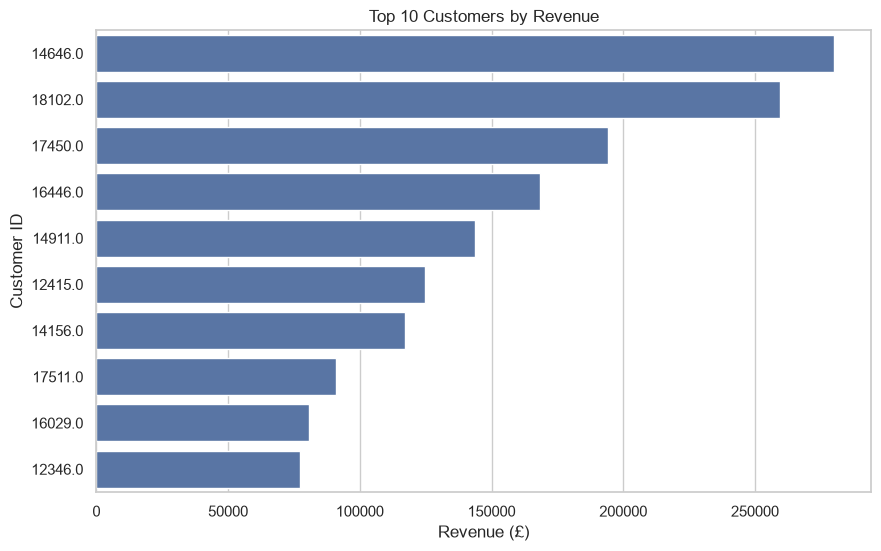

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_10_customers,
    x="Revenue",
    y=top_10_customers["CustomerID"].astype(str)
)

plt.title("Top 10 Customers by Revenue")

plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")

plt.show()

In [14]:
customer_revenue.to_csv(
    "../outputs/pareto_analysis.csv",
    index=False
)

print("Pareto Analysis Dataset Saved Successfully")

Pareto Analysis Dataset Saved Successfully
